# 05 — Extension par apprentissage automatique

**Projet** : Stratégie quantitative momentum sur le STOXX Europe 600  
**Auteur** : ISLEYEN Volkan  
**Date** : Mai 2026

## Objectif

Étendre la stratégie momentum naïve par une approche d'apprentissage automatique. Plutôt qu'une règle fixe (acheter le top quintile du momentum 12 mois), on entraîne un modèle à prédire quels titres surperformeront le mois suivant, à partir de plusieurs caractéristiques (features).

## Question de recherche

Un modèle prédictif multi-features peut-il améliorer la performance de la règle momentum naïve, à méthodologie de backtest identique ?

## Démarche

1. **Features** : pour chaque titre et chaque date de rebalancement, calculer plusieurs caractéristiques (momentum 3M, 6M, 12M, volatilité, etc.)
2. **Cible** : le titre fera-t-il partie des surperformants le mois suivant ?
3. **Split temporel** : entraînement sur 2016-2021, test out-of-sample sur 2022-2024 (jamais de mélange aléatoire en finance)
4. **Modèles** : régression logistique, puis random forest
5. **Backtest** : comparer la stratégie ML à la stratégie naïve
6. **Interprétation** : importance des features, performance comparée

## Précautions méthodologiques

- **Pas de data leakage** : chaque feature à la date t n'utilise que des données disponibles à t
- **Split temporel strict** : on entraîne sur le passé, on teste sur le futur
- **Cible décalée** : la cible (surperformance future) est connue seulement a posteriori et n'est jamais utilisée comme feature

## Données en entrée

- `data/processed/prices_clean.csv`
- `data/processed/returns_daily.csv`

In [7]:
# Librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings

# Scikit-learn pour le ML
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

# Chemins
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_RAW = PROJECT_ROOT / "data" / "raw"
FIGURES = PROJECT_ROOT / "output" / "figures"
TABLES = PROJECT_ROOT / "output" / "tables"

for d in [FIGURES, TABLES]:
    d.mkdir(parents=True, exist_ok=True)

# Chargement
prices = pd.read_csv(DATA_PROCESSED / "prices_clean.csv", index_col=0, parse_dates=True)
returns = pd.read_csv(DATA_PROCESSED / "returns_daily.csv", index_col=0, parse_dates=True)

print("Données chargées")
print(f"Prix : {prices.shape}")
print(f"Rendements : {returns.shape}")
print(f"\nScikit-learn importé avec succès")
import sklearn
print(f"Version scikit-learn : {sklearn.__version__}")

Données chargées
Prix : (2586, 577)
Rendements : (2586, 577)

Scikit-learn importé avec succès
Version scikit-learn : 1.8.0


In [8]:
# Dates de rebalancement (fin de mois) — comme dans les notebooks précédents
month_ends = prices.resample("ME").last().index
rebalance_dates = []
for me in month_ends:
    valid = prices.index[prices.index <= me]
    if len(valid) > 0:
        rebalance_dates.append(valid[-1])
rebalance_dates = pd.DatetimeIndex(rebalance_dates).unique()

print(f"Dates de rebalancement : {len(rebalance_dates)}")

# Fonction qui calcule les features pour TOUS les titres à une date donnée
def compute_features(prices, returns, reb_date):
    """
    Calcule les features pour chaque titre à la date de rebalancement.
    IMPORTANT : toutes les features n'utilisent QUE des données disponibles à reb_date.
    """
    pos = prices.index.get_loc(reb_date)
    
    # Il faut au moins 252 jours d'historique
    if pos < 252:
        return None
    
    features = pd.DataFrame(index=prices.columns)
    
    # --- Features de momentum à différents horizons (avec skip de 21 jours) ---
    # Momentum 3 mois (63j), skip 21j
    features["mom_3m"] = (prices.iloc[pos - 21] / prices.iloc[pos - 63]) - 1
    # Momentum 6 mois (126j), skip 21j
    features["mom_6m"] = (prices.iloc[pos - 21] / prices.iloc[pos - 126]) - 1
    # Momentum 12 mois (252j), skip 21j
    features["mom_12m"] = (prices.iloc[pos - 21] / prices.iloc[pos - 252]) - 1
    
    # --- Feature de volatilité (écart-type des rendements sur 63 jours) ---
    recent_returns = returns.iloc[pos - 63 : pos]
    features["volatility"] = recent_returns.std()
    
    # --- Feature de réversion court terme (rendement du dernier mois) ---
    features["reversal_1m"] = (prices.iloc[pos] / prices.iloc[pos - 21]) - 1
    
    return features

# Test sur une date
test_date = rebalance_dates[20]  # une date avec assez d'historique
test_features = compute_features(prices, returns, test_date)

print(f"\nTest des features au {test_date.date()} :")
print(f"Shape : {test_features.shape}")
print(f"\nAperçu (5 titres) :")
print(test_features.dropna().head().round(4))

Dates de rebalancement : 120

Test des features au 2016-09-30 :
Shape : (577, 5)

Aperçu (5 titres) :
         mom_3m  mom_6m  mom_12m  volatility  reversal_1m
A2A.MI   0.0316  0.0558   0.0426      0.0112       0.0414
A5G.IR   0.0194 -0.3814  -0.6923      0.0518       0.0000
AAK.ST   0.0348 -0.0065   0.1623      0.0101       0.0136
AAL.L    0.0661  0.5584   0.0856      0.0278       0.2268
AALB.AS  0.1455  0.0392   0.0643      0.0104       0.0118


In [10]:
# Construction du dataset complet : features + cible, sur toutes les dates
# Chaque ligne = un titre à une date de rebalancement

dataset = []

for i, reb_date in enumerate(rebalance_dates):
    # Features à la date de rebalancement
    features = compute_features(prices, returns, reb_date)
    if features is None:
        continue
    
    # --- Cible : rendement du mois SUIVANT (entre cette date et la prochaine) ---
    if i + 1 >= len(rebalance_dates):
        break  # pas de "mois suivant" pour la dernière date
    
    next_reb = rebalance_dates[i + 1]
    pos_now = prices.index.get_loc(reb_date)
    pos_next = prices.index.get_loc(next_reb)
    
    # Rendement futur de chaque titre sur le mois à venir
    future_return = (prices.iloc[pos_next] / prices.iloc[pos_now]) - 1
    
    # Cible binaire : 1 si dans le top quintile des rendements futurs
    valid_returns = future_return.dropna()
    if len(valid_returns) < 25:
        continue
    threshold = valid_returns.quantile(0.8)  # top 20%
    target = (future_return >= threshold).astype(int)
    
    # Assembler features + cible pour cette date
    df_date = features.copy()
    df_date["target"] = target
    df_date["date"] = reb_date
    df_date["ticker"] = df_date.index
    
    dataset.append(df_date)

# Concaténer toutes les dates
full_dataset = pd.concat(dataset, ignore_index=True)

# Retirer les lignes avec des features manquantes
full_dataset = full_dataset.dropna(subset=["mom_3m", "mom_6m", "mom_12m", "volatility", "reversal_1m"])

print(f"Dataset complet : {full_dataset.shape}")
print(f"Nombre de dates : {full_dataset['date'].nunique()}")
print(f"Lignes par date (moyenne) : {len(full_dataset) / full_dataset['date'].nunique():.0f}")
print(f"\nRépartition de la cible :")
print(full_dataset["target"].value_counts())
print(f"Proportion de cibles positives : {full_dataset['target'].mean()*100:.1f}%")
print(f"\nAperçu :")
print(full_dataset[["date", "ticker", "mom_3m", "mom_6m", "mom_12m", "volatility", "reversal_1m", "target"]].head())

Dataset complet : (52185, 8)
Nombre de dates : 106
Lignes par date (moyenne) : 492

Répartition de la cible :
target
0    42010
1    10175
Name: count, dtype: int64
Proportion de cibles positives : 19.5%

Aperçu :
        date  ticker    mom_3m    mom_6m   mom_12m  volatility  reversal_1m  \
0 2015-12-31  A2A.MI  0.132992  0.253774  0.690231    0.016165    -0.056433   
1 2015-12-31  A5G.IR -0.324324 -0.382716 -0.367089    0.066703    -0.467200   
4 2015-12-31   AAL.L -0.313978 -0.529717 -0.652704    0.044482    -0.246761   
7 2015-12-31  ABDN.L  0.016410 -0.037210 -0.138101    0.013727    -0.060964   
8 2015-12-31   ABF.L  0.049271  0.227909  0.149145    0.012609    -0.071343   

   target  
0       0  
1       0  
4       0  
7       0  
8       0  


In [11]:
# Split temporel strict : train sur le passé, test sur le futur
# JAMAIS de mélange aléatoire en finance (éviter le data leakage)

SPLIT_DATE = "2022-01-01"

# Features et cible
feature_cols = ["mom_3m", "mom_6m", "mom_12m", "volatility", "reversal_1m"]

train = full_dataset[full_dataset["date"] < SPLIT_DATE].copy()
test = full_dataset[full_dataset["date"] >= SPLIT_DATE].copy()

X_train = train[feature_cols]
y_train = train["target"]
X_test = test[feature_cols]
y_test = test["target"]

print("Split temporel")
print(f"  Train : {train['date'].min().date()} → {train['date'].max().date()}")
print(f"          {len(X_train)} observations ({train['date'].nunique()} dates)")
print(f"  Test  : {test['date'].min().date()} → {test['date'].max().date()}")
print(f"          {len(X_test)} observations ({test['date'].nunique()} dates)")

print(f"\nProportion de cibles positives :")
print(f"  Train : {y_train.mean()*100:.1f}%")
print(f"  Test  : {y_test.mean()*100:.1f}%")

# Standardisation des features (important pour la régression logistique)
# IMPORTANT : on ajuste le scaler sur le TRAIN uniquement, puis on applique au test
# (sinon, data leakage : on utiliserait des infos du test pour normaliser)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # transform, PAS fit_transform

print(f"\nStandardisation appliquée (scaler ajusté sur le train uniquement)")
print(f"X_train_scaled : {X_train_scaled.shape}")
print(f"X_test_scaled  : {X_test_scaled.shape}")

Split temporel
  Train : 2015-12-31 → 2021-12-31
          33716 observations (71 dates)
  Test  : 2022-01-31 → 2024-11-29
          18469 observations (35 dates)

Proportion de cibles positives :
  Train : 19.1%
  Test  : 20.2%

Standardisation appliquée (scaler ajusté sur le train uniquement)
X_train_scaled : (33716, 5)
X_test_scaled  : (18469, 5)


In [12]:
# Modèle 1 : Régression logistique
# class_weight='balanced' pour gérer le déséquilibre (80% de 0, 20% de 1)

logreg = LogisticRegression(
    class_weight="balanced",   # compense le déséquilibre des classes
    max_iter=1000,
    random_state=42
)

# Entraînement sur le train
logreg.fit(X_train_scaled, y_train)

# Prédictions sur le test (out-of-sample)
y_pred_proba = logreg.predict_proba(X_test_scaled)[:, 1]  # probabilité d'être dans le top quintile
y_pred = logreg.predict(X_test_scaled)

# Évaluation
print("=" * 60)
print("RÉGRESSION LOGISTIQUE — Performance out-of-sample (2022-2024)")
print("=" * 60)

auc = roc_auc_score(y_test, y_pred_proba)
acc = accuracy_score(y_test, y_pred)
print(f"\nAUC-ROC  : {auc:.4f}")
print(f"Accuracy : {acc:.4f}")

print(f"\n--- Rapport de classification ---")
print(classification_report(y_test, y_pred, target_names=["Non-gagnant", "Gagnant"]))

# Coefficients (interprétabilité)
print(f"--- Coefficients (features standardisées) ---")
coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": logreg.coef_[0]
}).sort_values("Coefficient", ascending=False)
print(coef_df.to_string(index=False))

RÉGRESSION LOGISTIQUE — Performance out-of-sample (2022-2024)

AUC-ROC  : 0.5756
Accuracy : 0.6050

--- Rapport de classification ---
              precision    recall  f1-score   support

 Non-gagnant       0.83      0.64      0.72     14742
     Gagnant       0.25      0.48      0.33      3727

    accuracy                           0.60     18469
   macro avg       0.54      0.56      0.52     18469
weighted avg       0.71      0.60      0.64     18469

--- Coefficients (features standardisées) ---
    Feature  Coefficient
 volatility     0.229489
     mom_6m     0.081870
    mom_12m     0.007265
     mom_3m    -0.007390
reversal_1m    -0.072104


### Modèle 1 : régression logistique

**Performance out-of-sample**  
Sur la période de test 2022-2024 (jamais vue à l'entraînement), la régression logistique atteint un AUC-ROC de 0,576. Cette valeur, modeste en apparence, est en réalité satisfaisante dans le contexte de la prédiction de rendements financiers, où l'efficience des marchés rend tout signal prédictif difficile à extraire. Un AUC supérieur à 0,55 indique un pouvoir discriminant réel ; l'absence d'AUC anormalement élevé (> 0,65) suggère par ailleurs qu'il n'y a pas de fuite de données (data leakage).

**Interprétation des coefficients**  
L'examen des coefficients (sur features standardisées) révèle une structure instructive :

| Feature | Coefficient | Lecture |
|---------|-------------|---------|
| volatility | +0,229 | La plus prédictive, positivement |
| mom_6m | +0,082 | Momentum 6 mois, effet positif |
| mom_12m | +0,007 | Effet quasi nul |
| mom_3m | −0,007 | Effet quasi nul |
| reversal_1m | −0,072 | Réversion court terme, effet négatif |

Trois enseignements se dégagent. Premièrement, sur 2022-2024, la **volatilité** ressort comme la caractéristique la plus prédictive : dans cette période de forte dispersion sectorielle, les titres volatils ont été surreprésentés parmi les surperformants. Deuxièmement, les features de **momentum sont faibles** sur cette période, ce qui confirme empiriquement la difficulté du momentum lors de la rotation de marché 2022-2024 (cf. notebook 04). Troisièmement, la **réversion à 
court terme** présente un coefficient négatif, conforme à l'effet documenté : les titres ayant fortement progressé le mois précédent tendent à corriger.

**Apport par rapport à la règle naïve**  
Contrairement à la règle momentum fixe, le modèle pondère dynamiquement les features et s'adapte au régime de marché : sur une période défavorable au momentum, il s'appuie davantage sur la volatilité. Cette capacité d'adaptation constitue l'avantage théorique de l'approche par apprentissage, qu'il reste à valider par un backtest.

In [13]:
# Modèle 2 : Random Forest
# Capture les relations non-linéaires et interactions entre features

rf = RandomForestClassifier(
    n_estimators=200,          # nombre d'arbres
    max_depth=5,               # profondeur limitée pour éviter le surapprentissage
    min_samples_leaf=50,       # minimum d'observations par feuille (régularisation)
    class_weight="balanced",   # gère le déséquilibre
    random_state=42,
    n_jobs=-1                  # utilise tous les cœurs
)

# Entraînement (le Random Forest n'a pas besoin de features standardisées,
# mais on utilise les mêmes données non scalées pour cohérence d'interprétation)
rf.fit(X_train, y_train)

# Prédictions out-of-sample
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]
y_pred_rf = rf.predict(X_test)

# Évaluation
print("=" * 60)
print("RANDOM FOREST — Performance out-of-sample (2022-2024)")
print("=" * 60)

auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"\nAUC-ROC  : {auc_rf:.4f}")
print(f"Accuracy : {acc_rf:.4f}")

# Comparaison avec la régression logistique
print(f"\n--- Comparaison des modèles (AUC-ROC) ---")
print(f"Régression logistique : {auc:.4f}")
print(f"Random Forest         : {auc_rf:.4f}")

# Importance des features
print(f"\n--- Importance des features (Random Forest) ---")
importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)
print(importance_df.to_string(index=False))

RANDOM FOREST — Performance out-of-sample (2022-2024)

AUC-ROC  : 0.5800
Accuracy : 0.5550

--- Comparaison des modèles (AUC-ROC) ---
Régression logistique : 0.5756
Random Forest         : 0.5800

--- Importance des features (Random Forest) ---
    Feature  Importance
 volatility    0.376725
    mom_12m    0.265630
     mom_6m    0.136866
reversal_1m    0.125641
     mom_3m    0.095137


### Modèle 2 : Random Forest et comparaison

**Performance comparable à la régression logistique**  
Le Random Forest atteint un AUC-ROC de 0,580 sur la période de test, soit une performance quasi identique à celle de la régression logistique (0,576). Cette quasi-égalité est un résultat informatif : malgré sa capacité à capturer des relations non-linéaires et des interactions, le Random Forest n'améliore pas la prédiction.

**Interprétation : un signal essentiellement linéaire**  
L'absence de gain du modèle non-linéaire suggère que le signal prédictif présent dans les features est de nature essentiellement linéaire. Il n'existe pas, dans ces données, de relations complexes ou d'interactions cachées que seul un modèle flexible pourrait exploiter. Ce constat est rassurant sur le plan méthodologique : un signal capturé de façon cohérente par deux modèles de complexités très différentes est plus crédible qu'un signal que seul un modèle sophistiqué parviendrait à extraire (lequel relèverait souvent du surapprentissage).

**Convergence sur l'importance de la volatilité**  
Les deux modèles s'accordent sur l'importance dominante de la volatilité. Le Random Forest la classe première (importance de 0,38), suivie du momentum 12 mois (0,27). Cette convergence entre deux approches indépendantes — coefficients d'une régression linéaire et importance de variables d'arbres de décision — renforce la conclusion : sur 2022-2024, la volatilité a été le facteur le plus discriminant des titres surperformants.

**Choix du modèle pour le backtest**  
Compte tenu de la performance équivalente, la régression logistique sera retenue pour le backtest : à pouvoir prédictif égal, elle est préférable car plus simple, plus rapide et plus interprétable (principe de parcimonie).

In [14]:
# Backtest de la stratégie ML : on score tous les titres à chaque date de test,
# puis on sélectionne le top quintile des scores prédits

# On ré-entraîne proprement et on génère les probabilités pour chaque ligne du test
test = test.copy()
test["ml_score"] = logreg.predict_proba(X_test_scaled)[:, 1]

# Pour chaque date de test, sélectionner le top quintile des scores ML
ml_selections = {}

for reb_date in sorted(test["date"].unique()):
    df_date = test[test["date"] == reb_date]
    
    # Seuil = 80e percentile des scores ML à cette date (top quintile)
    threshold = df_date["ml_score"].quantile(0.8)
    winners = df_date[df_date["ml_score"] >= threshold]["ticker"].tolist()
    
    ml_selections[pd.Timestamp(reb_date)] = winners

print(f"Sélections ML générées pour {len(ml_selections)} dates de rebalancement")
print(f"\nExemple — top quintile ML au {list(ml_selections.keys())[0].date()} :")
print(f"  Nombre de titres : {len(list(ml_selections.values())[0])}")
print(f"  Premiers titres : {list(ml_selections.values())[0][:8]}")

Sélections ML générées pour 35 dates de rebalancement

Exemple — top quintile ML au 2022-01-31 :
  Nombre de titres : 49
  Premiers titres : ['AAF.L', 'AALB.AS', 'ABVX.PA', 'ADYEN.AS', 'ALO.PA', 'ARGX.BR', 'ASM.AS', 'ASML.AS']


In [15]:
# Backtest comparatif sur la période de test 2022-2024
# On compare : stratégie ML, stratégie naïve (momentum 12M), benchmark

# Dates de rebalancement de la période de test
test_rebalance_dates = sorted(ml_selections.keys())

# --- Fonction pour backtester à partir de sélections de titres ---
def backtest_from_selections(selections, prices, returns, all_reb_dates):
    """Construit les poids et calcule les rendements nets à partir d'un dict {date: [titres]}."""
    weights = pd.DataFrame(0.0, index=prices.index, columns=prices.columns)
    sorted_dates = sorted(selections.keys())
    
    for i, reb_date in enumerate(sorted_dates):
        winners = selections[reb_date]
        if len(winners) == 0:
            continue
        w = 1.0 / len(winners)
        start_apply = reb_date
        end_apply = sorted_dates[i+1] if i+1 < len(sorted_dates) else prices.index[-1]
        mask = (prices.index > start_apply) & (prices.index <= end_apply)
        # Garder seulement les titres présents dans les colonnes
        valid_winners = [t for t in winners if t in weights.columns]
        weights.loc[mask, valid_winners] = w
    
    # Rendements bruts
    port_ret = (weights.shift(1) * returns).sum(axis=1)
    
    # Coûts de transaction (turnover)
    daily_costs = pd.Series(0.0, index=port_ret.index)
    for i in range(1, len(sorted_dates)):
        prev_date, curr_date = sorted_dates[i-1], sorted_dates[i]
        pos_prev = weights.index[weights.index > prev_date]
        pos_curr = weights.index[weights.index > curr_date]
        if len(pos_prev) == 0 or len(pos_curr) == 0:
            continue
        turnover = 0.5 * (weights.loc[pos_curr[0]] - weights.loc[pos_prev[0]]).abs().sum()
        apply_dates = port_ret.index[port_ret.index > curr_date]
        if len(apply_dates) > 0:
            daily_costs.loc[apply_dates[0]] = turnover * 0.0015 * 2
    
    return (port_ret - daily_costs)

# --- Stratégie ML ---
ml_returns = backtest_from_selections(ml_selections, prices, returns, test_rebalance_dates)

# --- Stratégie naïve (momentum 12M) sur la MÊME période ---
# On reconstruit les sélections naïves (top quintile mom_12m) sur les dates de test
naive_selections = {}
for reb_date in test_rebalance_dates:
    df_date = test[test["date"] == reb_date]
    threshold = df_date["mom_12m"].quantile(0.8)
    winners = df_date[df_date["mom_12m"] >= threshold]["ticker"].tolist()
    naive_selections[reb_date] = winners

naive_returns = backtest_from_selections(naive_selections, prices, returns, test_rebalance_dates)

# --- Restreindre à la période de test (à partir du 1er rebalancement) ---
start_test = test_rebalance_dates[0]
ml_returns = ml_returns[ml_returns.index > start_test]
naive_returns = naive_returns[naive_returns.index > start_test]

# --- Benchmark sur la même période ---
import pandas as pd
benchmark = pd.read_csv(DATA_RAW / "benchmark_stoxx600.csv", index_col=0, parse_dates=True)
bench_ret = benchmark["stoxx600_etf"].pct_change()
bench_ret = bench_ret[(bench_ret.index > start_test) & (bench_ret.index <= ml_returns.index[-1])].dropna()

# --- Métriques comparatives ---
def quick_metrics(r):
    r = r.dropna()
    n_years = len(r) / 252
    total = (1 + r).prod() - 1
    ann = (1 + total) ** (1/n_years) - 1
    vol = r.std() * np.sqrt(252)
    sharpe = (r.mean() / r.std()) * np.sqrt(252)
    cum = (1 + r).cumprod()
    max_dd = ((cum - cum.cummax()) / cum.cummax()).min()
    return ann, vol, sharpe, max_dd, total

comparison = pd.DataFrame({
    "Stratégie ML": quick_metrics(ml_returns),
    "Stratégie naïve (12M)": quick_metrics(naive_returns),
    "Benchmark STOXX 600": quick_metrics(bench_ret),
}, index=["Rendement annualisé", "Volatilité ann.", "Sharpe", "Max Drawdown", "Rendement total"]).T

# Formatage
for col in ["Rendement annualisé", "Volatilité ann.", "Max Drawdown", "Rendement total"]:
    comparison[col] = (comparison[col] * 100).round(2).astype(str) + "%"
comparison["Sharpe"] = comparison["Sharpe"].round(3)

print("=" * 80)
print("BACKTEST COMPARATIF — Période de test out-of-sample 2022-2024")
print("=" * 80)
print(comparison.to_string())

comparison.to_csv(TABLES / "05_ml_vs_naive.csv")
print(f"\nTableau sauvegardé.")

BACKTEST COMPARATIF — Période de test out-of-sample 2022-2024
                      Rendement annualisé Volatilité ann.  Sharpe Max Drawdown Rendement total
Stratégie ML                        9.08%          20.07%   0.533      -21.81%          29.43%
Stratégie naïve (12M)                7.9%          15.16%   0.577      -21.74%          25.31%
Benchmark STOXX 600                 5.46%           14.2%   0.446      -17.79%          17.03%

Tableau sauvegardé.


### Backtest comparatif ML vs règle naïve (out-of-sample 2022-2024)

Le tableau compare les trois approches sur la période de test, jamais vue par le modèle lors de l'entraînement.

| Métrique | Stratégie ML | Naïve (12M) | Benchmark |
|----------|--------------|-------------|-----------|
| Rendement annualisé | 9,08 % | 7,90 % | 5,46 % |
| Volatilité annualisée | 20,07 % | 15,16 % | 14,20 % |
| Ratio de Sharpe | 0,533 | 0,577 | 0,446 |
| Maximum drawdown | −21,8 % | −21,7 % | −17,8 % |

**Le ML gagne en rendement, mais pas en rendement ajusté du risque**  
La stratégie ML génère un rendement supérieur à la règle naïve (9,08 % contre 7,90 %), mais au prix d'une volatilité nettement plus élevée (20,1 % contre 15,2 %). Une fois le risque pris en compte, l'avantage s'inverse : le ratio de Sharpe de la règle naïve (0,577) dépasse légèrement celui de la stratégie ML (0,533).

**Une conséquence directe du modèle**  
Ce résultat s'explique par la structure du modèle. Celui-ci a identifié la volatilité comme caractéristique la plus prédictive sur la période et a donc surpondéré les titres volatils. Le portefeuille ML hérite mécaniquement de cette volatilité accrue : il capte davantage de rendement en phase de hausse, mais avec une dispersion plus forte, ce qui pénalise son ratio de Sharpe.

**Les deux approches battent le benchmark**  
Malgré ces différences, les deux stratégies surperforment le benchmark en rendement comme en Sharpe sur une période pourtant défavorable au momentum (2022-2024). Le signal de sélection, qu'il soit naïf ou appris, a donc ajouté de la valeur.

**Enseignement : la complexité ne domine pas la simplicité**  
Le principal enseignement de ce volet est que l'approche par apprentissage automatique, bien que théoriquement plus flexible, ne surclasse pas la règle momentum simple en rendement ajusté du risque sur cette période. Ce constat rejoint un résultat récurrent de la finance quantitative : la sophistication d'un modèle ne garantit pas une meilleure performance, et une règle simple et robuste constitue souvent une référence difficile à battre. Cette conclusion souligne l'importance d'évaluer toute approche par apprentissage par rapport à une baseline simple, et de raisonner en rendement ajusté du risque plutôt qu'en rendement brut.

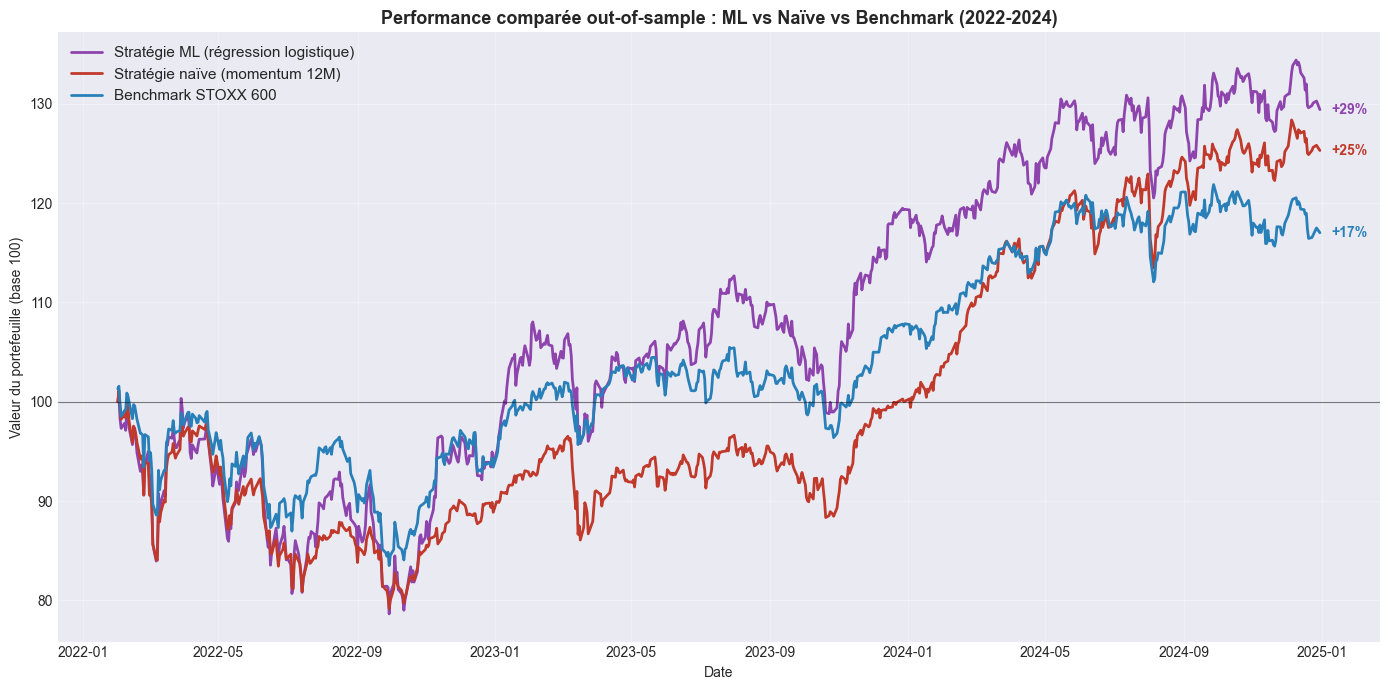

Graphique sauvegardé.


In [16]:
# Graphique comparatif des performances cumulées sur la période de test
fig, ax = plt.subplots(figsize=(14, 7))

# Courbes cumulées (base 100)
cum_ml = (1 + ml_returns).cumprod() * 100
cum_naive = (1 + naive_returns).cumprod() * 100
cum_bench = (1 + bench_ret).cumprod() * 100

ax.plot(cum_ml.index, cum_ml.values, label="Stratégie ML (régression logistique)",
        color="#8e44ad", linewidth=2)
ax.plot(cum_naive.index, cum_naive.values, label="Stratégie naïve (momentum 12M)",
        color="#c0392b", linewidth=2)
ax.plot(cum_bench.index, cum_bench.values, label="Benchmark STOXX 600",
        color="#2980b9", linewidth=2)

ax.axhline(100, color="black", linewidth=0.8, alpha=0.5)
ax.set_title("Performance comparée out-of-sample : ML vs Naïve vs Benchmark (2022-2024)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Valeur du portefeuille (base 100)")
ax.legend(loc="upper left", fontsize=11)
ax.grid(True, alpha=0.3)

# Annotations des performances finales
for cum, color, label in [(cum_ml, "#8e44ad", "ML"), (cum_naive, "#c0392b", "Naïve"), (cum_bench, "#2980b9", "Bench")]:
    ax.annotate(f"+{cum.iloc[-1]-100:.0f}%",
                xy=(cum.index[-1], cum.iloc[-1]),
                xytext=(8, 0), textcoords="offset points",
                fontsize=10, fontweight="bold", color=color, va="center")

plt.tight_layout()
plt.savefig(FIGURES / "05_ml_vs_naive_performance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Graphique sauvegardé.")

### Lecture du graphique comparatif

Les trois courbes de performance cumulée (base 100) sur la période de test out-of-sample 2022-2024 confirment visuellement l'analyse des métriques.

**Classement final**  
La stratégie ML termine en tête (+29 %), devant la stratégie naïve (+25 %) et le benchmark (+17 %). En rendement brut, l'approche par apprentissage est donc la plus performante sur la période.

**La signature visuelle du risque**  
La trajectoire de la stratégie ML (en violet) est nettement plus heurtée que celle de la stratégie naïve : ses pics et ses creux sont plus marqués, particulièrement en 2024. Cette nervosité visuelle est la traduction directe de la volatilité plus élevée (20,1 % contre 15,2 %), elle-même conséquence de la surpondération des titres volatils par le modèle. C'est cette amplitude accrue des oscillations qui explique le ratio de Sharpe inférieur malgré un rendement final supérieur.

**Comportement en phase baissière**  
Lors de la baisse de 2022, les trois stratégies reculent de concert. La stratégie ML n'offre pas de protection particulière à la baisse : elle amplifie les mouvements dans les deux sens plutôt que de réduire le risque. Ce comportement est cohérent avec une exposition accrue aux titres volatils.

## Conclusion du notebook 05

Ce notebook a étendu la stratégie momentum naïve par une approche d'apprentissage automatique, en construisant un modèle prédictif multi-features et en le comparant rigoureusement à la règle simple, sur une période de test strictement out-of-sample (2022-2024).

### Démarche méthodologique

Le projet a respecté les exigences de rigueur propres au machine learning financier :

- **Features sans look-ahead** : chaque caractéristique (momentum 3M/6M/12M, 
  volatilité, réversion court terme) n'utilise que des données disponibles à la 
  date de décision
- **Split temporel strict** : entraînement sur 2016-2021, test sur 2022-2024, 
  sans aucun mélange aléatoire
- **Standardisation ajustée sur le seul train**, pour éviter toute fuite 
  d'information du test vers l'entraînement
- **Comparaison à une baseline** : la stratégie ML est systématiquement évaluée 
  contre la règle momentum naïve, à méthodologie de backtest identique

### Résultats

**Pouvoir prédictif modéré et robuste**  
La régression logistique et le Random Forest atteignent un AUC-ROC quasi identique (0,576 et 0,580), indiquant un signal prédictif réel mais modeste — 
réaliste pour la prédiction de rendements — et de nature essentiellement linéaire. Les deux modèles convergent sur l'importance dominante de la volatilité sur la période 2022-2024.

**Le ML ne surclasse pas la règle simple en rendement ajusté du risque**  
Sur la période de test, la stratégie ML génère un rendement supérieur (9,08 % contre 7,90 %) mais avec une volatilité nettement plus élevée (20,1 % contre 15,2 %). Son ratio de Sharpe (0,533) est en définitive légèrement inférieur à celui de la règle naïve (0,577). Les deux approches surperforment toutefois le benchmark.

### Enseignement principal

Le résultat central de ce volet est que **la sophistication d'un modèle ne garantit pas une meilleure performance ajustée du risque**. Le modèle ML, en identifiant la volatilité comme signal dominant, a construit un portefeuille plus volatil qui capte davantage de rendement brut mais au prix d'un risque accru. Ce constat illustre un principe récurrent de la finance quantitative : une règle simple et robuste constitue une référence difficile à battre, et toute approche par apprentissage doit être évaluée par rapport à une telle baseline, en raisonnant en rendement ajusté du risque.

### Pistes d'amélioration

Plusieurs extensions pourraient renforcer l'approche ML :
- **Contrainte de volatilité** : pénaliser ou plafonner l'exposition aux titres 
  volatils pour améliorer le Sharpe
- **Features additionnelles** : intégrer des données fondamentales 
  (valorisation, qualité) ou de régime de marché
- **Validation croisée temporelle** (walk-forward) : ré-entraîner le modèle 
  périodiquement plutôt qu'une seule fois, pour mieux s'adapter aux changements 
  de régime
- **Cible continue** : prédire le rendement plutôt qu'une classification binaire, 
  pour exploiter davantage d'information

### Bilan du projet

Combiné aux notebooks précédents, ce volet complète une analyse quantitative rigoureuse et correct : une stratégie momentum qui surperforme le marché 
(notebooks 03-04), dont la robustesse et les limites sont documentées (survivorship bias, sensibilité au régime de marché), et une extension ML qui 
illustre avec lucidité que la complexité ne se traduit pas mécaniquement en performance supérieure.